# Logistic Equation Simulation (1st-Order ODE)

**Methods:** Analytical Integration (Partial Fractions), NumPy, Matplotlib

### Overview
This notebook models the population growth of a species in a controlled environment with carrying capacity constraints using the 1st-order logistic differential equation:
$$\frac{dN}{dt} = (a_3 - a_4 N)N$$

---

### Investigating the propagation of species


Organisms of the same species are placed in a controlled environment, where they reproduce and increase their population, denoted by $N$. The population growth follows a logistic curve, which can be described by the following first-order ODE:

\begin{align}
\frac{dN}{dt} = (a_3-a_4N)N
\end{align}

Here, $a_3$ and $a_4$ are parameters of the system. For this investigation, the growth rate $a_3$ is assumed to be 0.05/day, while $a_4$ is assumed to be 0.00005/organism/day and represents the effect of the carrying capacity.

This Python notebook investigates how the population $N$ changes over time by constructing a time-series plot. The population behavior is analyzed under different initial conditions, where $N_{t=0}=N_0$ (Dirichlet condition):

1. $N_0$ = 100 organisms
2. $N_0$ = 2000 organisms

---


#### Importing necessary modules

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#### Assigning the parameters and the $t$ array.

In [8]:
a3 = 0.05
a4 = 0.00005
t = np.linspace(0,150,1000)

By the given equation we can show the solution of finding the exact solution below :
\begin{align}
\frac{dN}{dt} &= (a_3 - a_4 N)N
\end{align}

\begin{align}
\int \frac{1}{(a_3 - a_4 N)N} dN &= \int dt
\end{align}

Using partial fractions, we write

\begin{align}
\frac{A}{N} + \frac{B}{a_3 - a_4 N} &= \frac{1}{(a_3 - a_4 N)N}
\end{align}

Solving for A and B

\begin{align}
a_3A+(B-a_4A)N &= 1
\end{align}

We got :

\begin{align}
A = \frac{1}{a_3}, B= \frac{a_4}{a_3}
\end{align}

Substitute back to our main equation

\begin{align}
\frac{1}{a_3}\left(\int \frac{1}{N} dN + \int \frac{a_4}{a_3 - a_4 N} dN \right) &= \int dt
\end{align}

\begin{align}
\frac{1}{a_3}\left(\ln |N| + (-\ln |a_3-a_4 N|) \right) + C_n &= t
\end{align}

\begin{align}
\ln \left| \frac{N}{a_3-a_4 N} \right| = a_3(t+C_m)
\end{align}

\begin{align}
\frac{N}{a_3-a_4 N} = C_k e^{a_3 t}
\end{align}

at t=0 :

\begin{align}
C_k &= \frac{N_0}{a_3 - a_4 N_0}
\end{align}

Substitute $C_k$ back into equation we get from derivative to gain exact solution

\begin{align}
\frac{N}{a_3 - a_4 N} &= \frac{N_0}{a_3 - a_4 N_0} e^{a_3 t}
\end{align}

\begin{align}
\left(\frac{a_3}{N} - \frac{a_4 N}{N}\right) &= \frac{a_3 - a_4 N_0}{N_0 e^{a_3 t}}
\end{align}

\begin{align}
\frac{a_3}{a_4 + \frac{a_3 - a_4 N_0}{N_0 e^{a_3 t}}} &= N
\end{align}

Then defined new $C$ and $N$ for the simplified equation:

\begin{align}
C &= \frac{a_3 - a_4 N_0}{N_0}
\end{align}

\begin{align}
N &= \frac{a_3}{a_4 + C e^{-a_3 t}}
\end{align}


#### Define a function of the exact solution.

In [9]:
def exact(n):
  C = (a3-a4*n)/n #where n is N_0 from the equation here
  N=a3/(a4+C*np.exp(-a3*t))
  return N

#### Applying the function

In [10]:
N_100 = exact(100)
N_2000 = exact(2000)

#### Making a basic figure

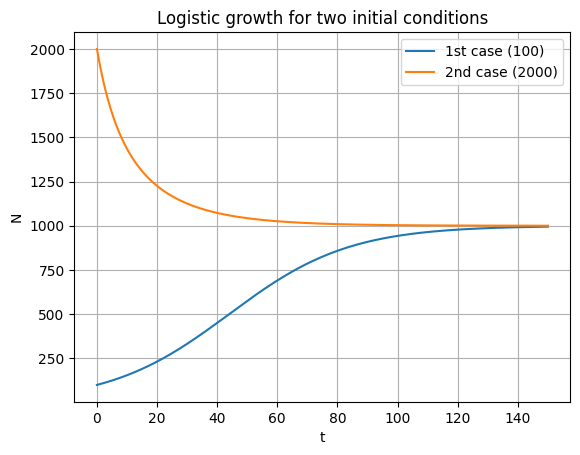

In [11]:
plt.plot(t,N_100,label='1st case (100)')
plt.plot(t,N_2000,label='2nd case (2000)')
plt.xlabel("t")
plt.ylabel("N")
plt.title('Logistic growth for two initial conditions')
plt.grid(True)
plt.legend()

---

### Discussion based on the time-series and the solution tool

As we can see from the two examples above, giving $N_0$ to be 100 and 2000, both of them go to one value of 1000. By simply observing the equation

\begin{align}
N &= \frac{a_3}{a_4 + C e^{-a_3 t}}
\end{align}

we can see that when $t$ goes to infinity, the term $C e^{-a_3 t}$ becomes 0. Therefore, what we have left is $\frac{a_3}{a_4}$, which in this case is $\frac{0.05}{0.00005}$, which is 1000. Hence, we get that the equation goes to 1000.

As for any other conditions, if $N_0$ is more than 1000, then the graph will show negative feedback, and if $N_0$ is less than 1000, then the graph will show positive feedback.

---
The given equation :
\begin{align}
\frac{dN}{dt} &= (a_3 - a_4 N)N
\end{align}
From the above equation we can form the following graph below


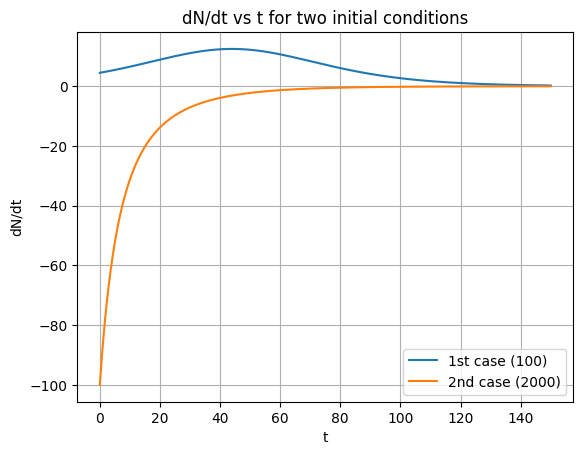

In [12]:
def dnbydt(n):
    N = exact(n)
    dndt = (a3-a4*N)*N
    return dndt

dndt_100 = dnbydt(100)
dndt_2000 = dnbydt(2000)
plt.plot(t,dndt_100,label='1st case (100)')
plt.plot(t,dndt_2000,label='2nd case (2000)')
plt.xlabel("t")
plt.ylabel("dN/dt")
plt.title('dN/dt vs t for two initial conditions')
plt.grid(True)
plt.legend()

From the graph illustrated above, we can see that the slope of the first case is entirely in the first quadrant, meaning it is positive, which implies positive feedback. Its steepest point is around $t = 40∼60$. However, for the second case, the graph lies in the fourth quadrant, meaning it is entirely negative, which implies negative feedback.